# Analysis and Visualization of data

## Introduction
Our goal is to find out realtions between world happiness scores and factors like GDP, employment, etc. We will use several machine learning models to predict the happiness score based on the factors.

We also wish to see if different factors are more important in different regions of the world.

### Classification of problem
This is a regression problem, as we are trying to predict a continuous value, the happiness score.

### The data
The data is gathered from Kaggle, and is a combination of several datasets.
- World happiness report
- World employment data
- World economic data

### The Analysis
1. Mean, median, standard deviation
2. Correlation analysis
3. Linear Regression analysis
4. Neural Network
5. Decision Tree
6. Random Forest
7. Finding correlations in different regions
8. Conclusion


## 0. Import dependencies and Load data

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('default')

# Load the dataset
if not Path('data/processed_data.csv').exists():
    raise Exception('Please run the scripts in the data_preprocessing notebook first. And make sure the data folder contains the combined_data.csv file.')

data = pd.read_csv('data/processed_data.csv')
mean_data = data[['Happiness_Score_Mean', 'Unemployment_Rate_Mean', 'GDP_Per_Capita_Mean', 'GDP_Per_Capita_Growth_Mean']]
data_without_mean = data.drop(columns=['Happiness_Score_Mean', 'Unemployment_Rate_Mean', 'GDP_Per_Capita_Mean', 'GDP_Per_Capita_Growth_Mean'])

# Check for null values and visualize the data
print(data.isnull().sum()[data.isnull().sum() > 0])
data.head()

OSError: 'light_background' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

## 1. Mean, median, standard deviation
### Import Libraries and Load Data

### 1.1 Finding the mean, median and standard deviation of the data

In [2]:
# Calculate mean for each numerical column
mean_values = mean_data.mean()
print("\033[1mMean Values:\033[0m\n", mean_values)

# Calculate median for each numerical column
median_values = mean_data.median()
print("\n\033[1mMedian Values:\033[0m\n", median_values)

# Calculate standard deviation for each numerical column
std_values = mean_data.std()
print("\n\033[1mStandard Deviation:\033[0m\n", std_values)

Mean Values:
 Happiness_Score_Mean              5.495258
Unemployment_Rate_Mean            6.688864
GDP_Per_Capita_Mean           16157.522128
GDP_Per_Capita_Growth_Mean        2.062089
dtype: float64

Median Values:
 Happiness_Score_Mean             5.582200
Unemployment_Rate_Mean           5.136000
GDP_Per_Capita_Mean           6463.266125
GDP_Per_Capita_Growth_Mean       1.827293
dtype: float64

Standard Deviation:
 Happiness_Score_Mean              1.129419
Unemployment_Rate_Mean            4.955676
GDP_Per_Capita_Mean           21293.149892
GDP_Per_Capita_Growth_Mean        2.224269
dtype: float64


### 1.2 Visualize data

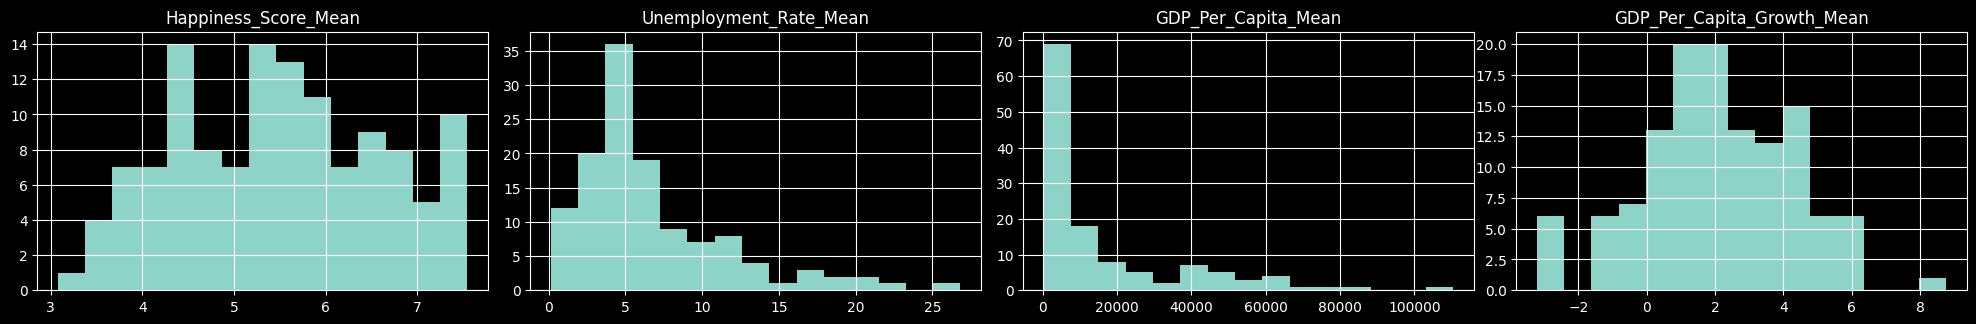

In [4]:
# Plot histograms
mean_data.hist(bins=15, figsize=(20, 15), layout=(5, 4))
plt.tight_layout()
plt.show()

## 2. Correlation analysis

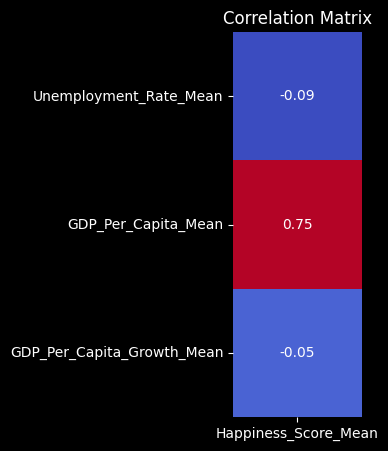

In [120]:
# Compute correlation matrix
corr_matrix = mean_data.corr()
corr_matrix = corr_matrix['Happiness_Score_Mean'].drop('Happiness_Score_Mean')

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False, square=True)
plt.title('Correlation Matrix')
plt.show()

## 3. Regression analysis
### 3.1 Simple Linear Regression

In [53]:
X = data[['Unemployment_Rate_Mean']]
y = data['Happiness_Score_Mean']
X_train, X_test_simple, y_train, y_test_simple = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Coefficient
print("Coefficient:", linear_model.coef_)

# Intercept
print("Intercept:", linear_model.intercept_)

y_pred_simple = linear_model.predict(X_test_simple)

Coefficient: [-0.02840184]
Intercept: 5.650355917256279


### 3.2 Multiple Linear Regression

In [54]:
X = data[['Unemployment_Rate_Mean', 'GDP_Per_Capita_Mean', 'GDP_Per_Capita_Growth_Mean']]
y = data['Happiness_Score_Mean']
X_train, X_test_multiple, y_train, y_test_multiple = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the Linear Regression model
multiple_linear_model = LinearRegression()

# Train the model
multiple_linear_model.fit(X_train, y_train)

# Coefficient
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': multiple_linear_model.coef_
})
print(coefficients)

# Intercept
print("Intercept:", multiple_linear_model.intercept_)

y_pred_multiple = multiple_linear_model.predict(X_test_multiple)

                     Variable  Coefficient
0      Unemployment_Rate_Mean    -0.010336
1         GDP_Per_Capita_Mean     0.000038
2  GDP_Per_Capita_Growth_Mean    -0.016243
Intercept: 4.948927758532204


### 3.3 Visualizing the results

In [55]:
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mse_multiple = mean_squared_error(y_test_multiple, y_pred_multiple)

r2_simple = r2_score(y_test_simple, y_pred_simple)
r2_multiple = r2_score(y_test_multiple, y_pred_multiple)

print("\n\033[1mPerformance:\033[0m\n")
print("Simple Linear Regression Model:")
print("MSE:", mse_simple)
print("R^2:", r2_simple)
print("\nMultiple Linear Regression Model:")
print("MSE:", mse_multiple)
print("R^2:", r2_multiple)


Performance:

Simple Linear Regression Model:
MSE: 1.5224825954021841
R^2: -0.051946274164685

Multiple Linear Regression Model:
MSE: 0.7150095792605051
R^2: 0.5059702717347278


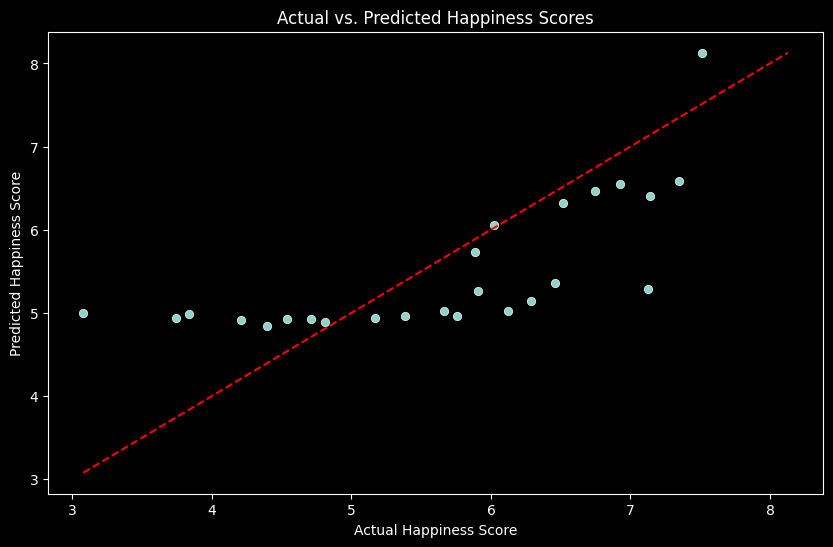

In [56]:
# Create a DataFrame with actual and predicted values
results_df = pd.DataFrame({'Actual': y_test_multiple, 'Predicted': y_pred_multiple})

# Plot the results
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', data=results_df)
plt.plot([results_df.min().min(), results_df.max().max()], [results_df.min().min(), results_df.max().max()], 'r--')
plt.title('Actual vs. Predicted Happiness Scores')
plt.xlabel('Actual Happiness Score')
plt.ylabel('Predicted Happiness Score')
plt.show()

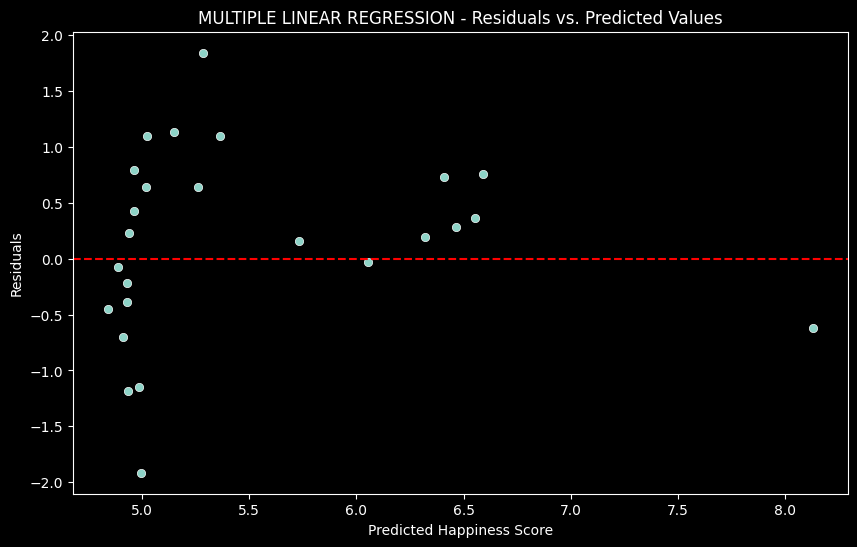

In [57]:
# Calculate residuals
residuals = y_test_multiple - y_pred_multiple

# Plot residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_multiple, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('MULTIPLE LINEAR REGRESSION - Residuals vs. Predicted Values')
plt.xlabel('Predicted Happiness Score')
plt.ylabel('Residuals')
plt.show()

## 4. Neural Network

### 4.1 Scale features

In [58]:
from sklearn.preprocessing import StandardScaler

X = data[['Unemployment_Rate_Mean', 'GDP_Per_Capita_Mean', 'GDP_Per_Capita_Growth_Mean']]
y = data['Happiness_Score_Mean']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X=X_test)

### 4.2 Train the model

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define the neural network architecture
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))  # For regression

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train_scaled, y_train, 
                    validation_split=0.1, 
                    epochs=100, 
                    batch_size=32, 
                    verbose=1)

Epoch 1/100


/Users/christianveiby/Lokale dokumenter/ME276DS-SDSE-The-Happiness-Project/env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 30.1414 - mae: 5.3710 - val_loss: 18.4867 - val_mae: 4.0947
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 19.6680 - mae: 4.2614 - val_loss: 9.9689 - val_mae: 2.8148
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 10.1095 - mae: 2.8644 - val_loss: 4.1111 - val_mae: 1.6353
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.3134 - mae: 1.6920 - val_loss: 6.8448 - val_mae: 2.0700
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.6667 - mae: 1.9400 - val_loss: 5.4676 - val_mae: 1.9163
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.2670 - mae: 1.7427 - val_loss: 2.4080 - val_mae: 1.2941
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.0305 - mae: 1.4533 - val_loss: 2.0765 - val_mae: 1.2545
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.3099 - mae: 1.5494 - val_loss: 2.3653 - val_mae: 1.2579
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.6583 - mae: 1.6286 -

### 4.3 Evaluate the model

In [60]:
# Evaluate on the test set
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print("\nNeural Network Results:")
print("Test MSE (loss):", loss)
print("Test MAE:", mae)

# Make predictions
y_pred_nn = model.predict(X_test_scaled).flatten()

mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("Calculated MSE:", mse_nn)
print("R-squared:", r2_nn)


Neural Network Results:
Test MSE (loss): 0.419038325548172
Test MAE: 0.535371720790863
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Calculated MSE: 0.41903829464645825
R-squared: 0.7104690890280947


### 4.4 Visualize the results

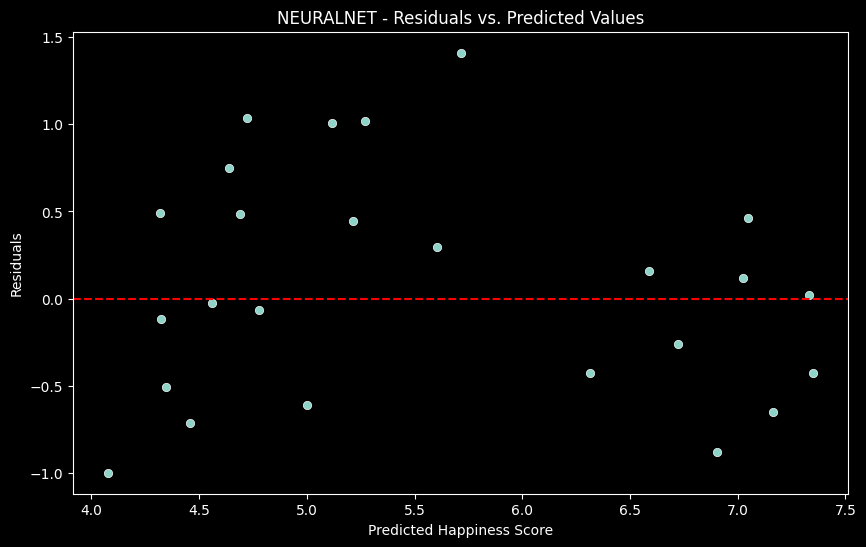

In [61]:
# Calculate residuals
residuals = y_test - y_pred_nn

# Plot residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_nn, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('NEURALNET - Residuals vs. Predicted Values')
plt.xlabel('Predicted Happiness Score')
plt.ylabel('Residuals')
plt.show()

## 5. Decision Tree

### 5.1 Train the model

In [62]:
from sklearn.tree import DecisionTreeRegressor

X = data[['Unemployment_Rate_Mean', 'GDP_Per_Capita_Mean', 'GDP_Per_Capita_Growth_Mean']]
y = data['Happiness_Score_Mean']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

### 5.2 Evaluate the model

In [63]:
# Predict on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate performance
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print("MSE:", mse_dt)
print("R-squared:", r2_dt)

Decision Tree Results:
MSE: 0.6415335752400289
R-squared: 0.5567378856984404


### 5.3 Visualize the results

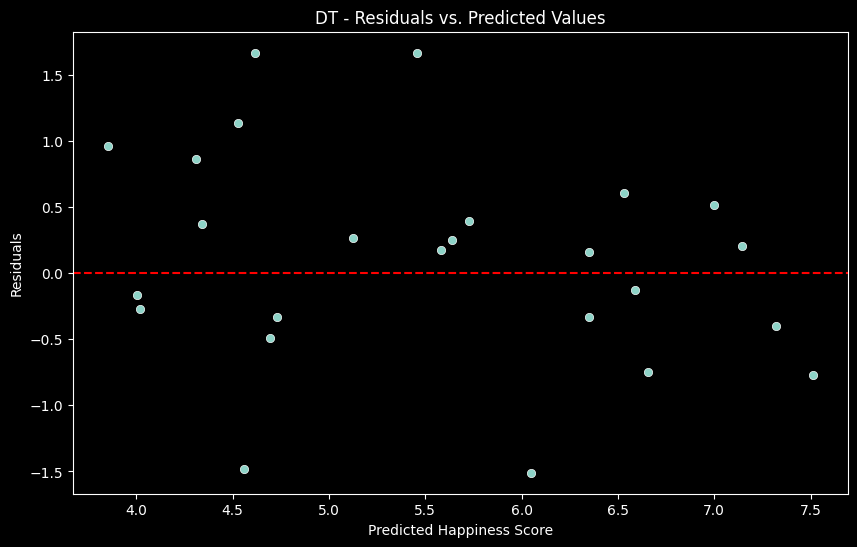

In [64]:
# Calculate residuals
residuals = y_test - y_pred_dt

# Plot residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_dt, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('DT - Residuals vs. Predicted Values')
plt.xlabel('Predicted Happiness Score')
plt.ylabel('Residuals')
plt.show()

## 6. Random Forest

### 6.1 Train the model

In [65]:
from sklearn.ensemble import RandomForestRegressor

# Create and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### 6.2 Evaluate the model

In [66]:
# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate performance
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Results:")
print("MSE:", mse_rf)
print("R-squared:", r2_rf)


Random Forest Results:
MSE: 0.283470051656621
R-squared: 0.8041388022575845


### 6.3 Visualize the results

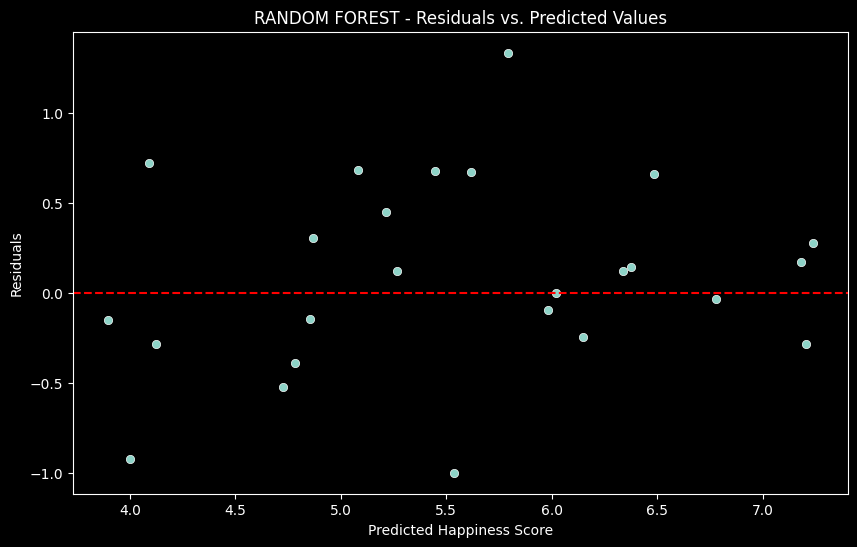

In [67]:
# Calculate residuals
residuals = y_test - y_pred_rf

# Plot residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('RANDOM FOREST - Residuals vs. Predicted Values')
plt.xlabel('Predicted Happiness Score')
plt.ylabel('Residuals')
plt.show()

## 7. Finding correlations in different regions
#### Why?
Data needs to be split into different regions. 
The reason behind this is to evaluate which factors are more important in different regions.
The regions in consideration are the following continents:
- Americas
- Europe
- Asia
- Africa
- Oceania

#### How?
Comparing the correlation of the factors with the happiness score in different regions. 
This will indicate which factors are more important in different regions.

### 7.1 Find correlations in different regions


In [116]:
# Find the mean of the the combined years for each region
regional_data = data.groupby('region')[['region', 'Happiness_Score_Mean', 'Unemployment_Rate_Mean', 'GDP_Per_Capita_Mean', 'GDP_Per_Capita_Growth_Mean']]

# Define the columns of interest
variables = ['Happiness_Score_Mean', 'Unemployment_Rate_Mean', 
             'GDP_Per_Capita_Mean', 'GDP_Per_Capita_Growth_Mean']

# Dictionary to store correlations by region
correlations = {}

# Group the data by region
for region, group in regional_data:
    # Compute correlation matrix for the subset
    corr_matrix = group[variables].corr()
    corr_matrix.drop('Happiness_Score_Mean', inplace=True)
    # Store the correlation matrix
    correlations[region] = corr_matrix['Happiness_Score_Mean']


### 7.2 Visualize the results

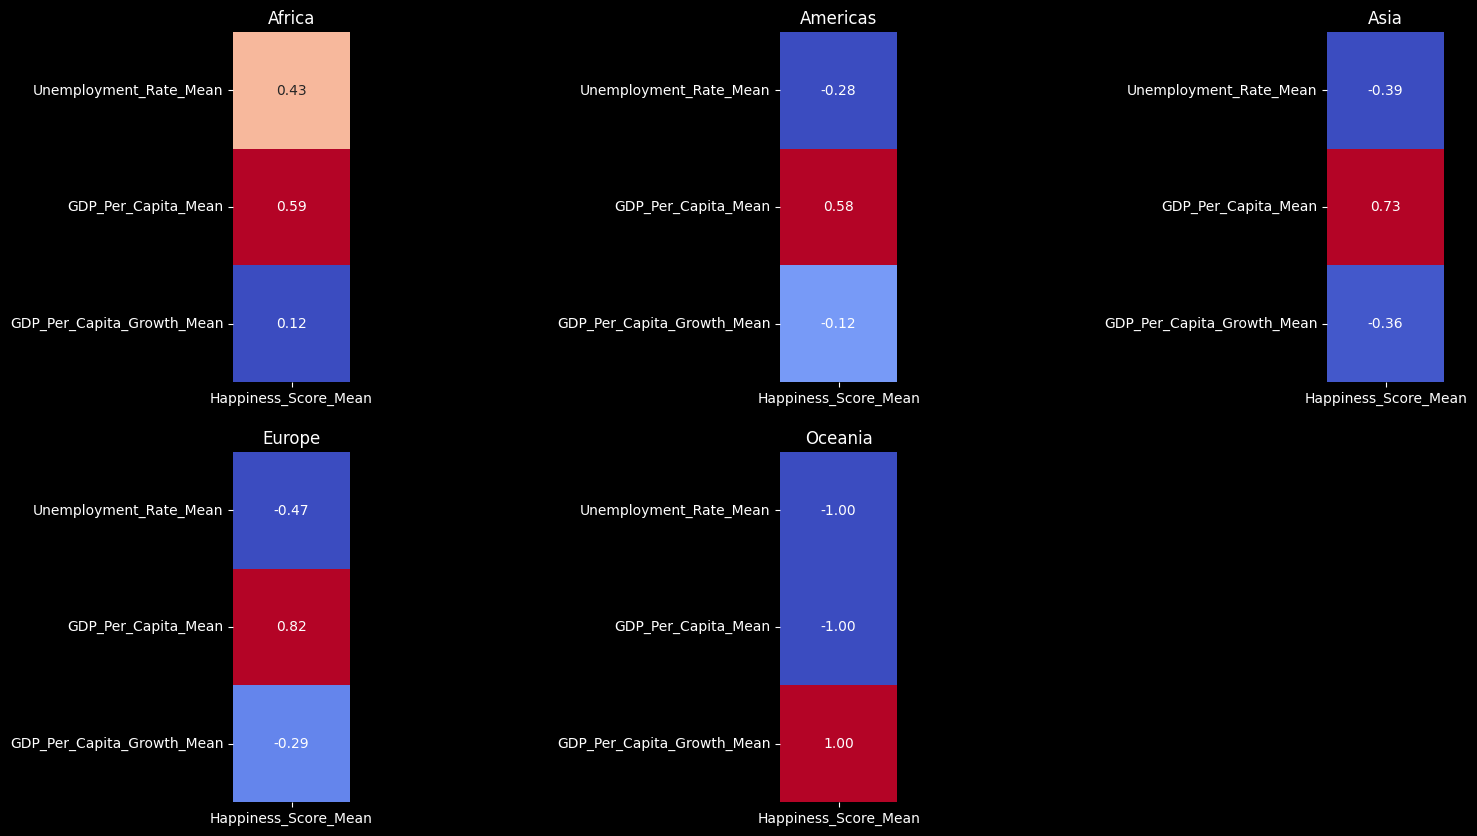

In [117]:
# Plot the correlation matrix for each region
plt.figure(figsize=(20, 10))
for i, (region, corr_matrix) in enumerate(correlations.items()):
    plt.subplot(2, 3, i + 1)
    sns.heatmap(corr_matrix.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False, square=True)
    plt.title(f'{region}')

## 8. Conclusion

<strong>This is a summary. <br> Refer to full report (can be found in repo) for detailed discussion about data, metholody and finding.</strong>

### 8.1 Summary of data

The data used for this analysis is a combination of several datasets. The data is gathered from Kaggle, links to datasets are provided in the report and can be found in the data_preprocessing notebook.

Datasets:
- World happiness report
- World employment data
- World economic data (gdp and gdp growth)
- World region data (for splitting data into regions)

### 8.2 Summary of methodology

The data is first preprocessed, then analyzed using several machine learning models. The models used are:
- Linear Regression
- Neural Network
- Decision Tree
- Random Forest

### 8.3 Summary of findings

We found that the models had difficulty predicting the happiness score. However, the most significant find was that different factors are more important in different regions. For example, in Europe, GDP is more important than employment, while in Africa, employment is much more correlated to happiness than in Europe.